## Machine Learning - CA2.2
## Matthew Riddell - D00245674

For this CA, I wish to look at do a simple classification between Cats and Dogs 
I selected the following Dataset from kaggle:

https://www.kaggle.com/datasets/tongpython/cat-and-dog

For this project I want to training some machine learning models to detect whether the image contains a cat or a dog 

Binary classification Computer Vision

I will take the data and divide it into batches of 32 images and each image will be resized to 128 x 128

Then the training and test data will be normalized by rescaling the values of the pixes into a range between 0 and 1 

For this project I want to make 3 Models:

Simple CNN:

2 Conv layers, 2 pooling layers, default parameters

Tuned Simple CNN:

The same arhcitecture but I wish to adjust the epoch and the learning rate 

I wish to do three training seesions for this model:

10 epochs

25 epochs

50 epochs

More complex CNN:

I add an extra Conv and Pooling Layer + the adjusted parameters from the Tuned Simple CNN

I wish to do three training seesions for this model:

10 epochs

25 epochs

50 epochs

With these models I wish to compare and contrast their performance via looking at their Accuracy and Loss values during testing 


### This code will also be uploaded to my github repo here:

https://github.com/Matthew-Riddell/Machine-Learning-CA2.2


Code is adapted from module exercises and from tensorflow documentation

#### Package Imports

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam

#### Dataset folders

In [4]:
datasets_folder = "C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Machine Learning/CAs/CA2.2/Machine-Learning-CA2.2/dataset/"
train_folder = datasets_folder + "training_set/training_set/"
test_folder = datasets_folder + "test_set/test_set/"

#### Loading the dataset and dividing the images into batches

loads the images from the folders and keras applies labels

resizes the images to 128x128 and takes them in batches of 32 images at a time

image_dataset_from_directory() then returns the count of x (images) and y (classes) which are cats and dogs 

In [5]:
# https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image_dataset_from_directory

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    train_folder,
    image_size=(128, 128),
    batch_size=32
)

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    test_folder,
    image_size=(128, 128),
    batch_size=32
)

Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.


#### Normalization

rescaling the pixels to be values between 0 and 1 so they work better in the neural network

the normalization is then applied to each image in the datasets via the x (image) and y (class) values 

In [6]:
# https://www.tensorflow.org/api_docs/python/tf/keras/layers/Rescaling

normalization = layers.Rescaling(1./255)
train_data = train_data.map(lambda x, y: (normalization(x), y))
test_data = test_data.map(lambda x, y: (normalization(x), y))

### Simple CNN Model

#### Making the CNN Model

here i make a simple sequential CNN model like so:

Input layer -> Convolutional Layer 1 -> Pooling Layer 1 -> Convolutional Layer 2 -> Pooling Layer 2 -> Flatten Layer -> Dense Layer -> Output Layer

The convolutional layers will use the ReLu activation function which outputs a 1 for positive inputs and 0 for negatives 

The final layer will use the sigmoid activation function which scales the output into a range between 0 and 1 and any values at > 0.5 become 1 and any < 0.5 become 0 



In [14]:
# https://www.tensorflow.org/guide/keras/sequential_model?hl=en

model = Sequential()

# Convolutional Layer 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))

# Pooling Layer 1
model.add(MaxPooling2D(pool_size=(2,2)))

# Convolutional Layer 2
model.add(Conv2D(64, (3,3), activation='relu'))

# Pooling Layer 2
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(64, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

#### Model shape and size

In [17]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,705,921 (14.14 MB)

 Trainable params: 3,705,921 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

#### Compiling the Model

preparing the model for training using the adam optimizer and using binary cross entropy as the loss function since it is a binary classification

In [ ]:
# https://www.tensorflow.org/api_docs/python/tf/keras/Model
# https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#### Training the Model

training this first model on 5 epoch

In [18]:
model.fit(train_data, epochs=5)

Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 71s 273ms/step - accuracy: 0.4979 - loss: 0.6936
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 79s 312ms/step - accuracy: 0.4914 - loss: 0.6932
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 62s 247ms/step - accuracy: 0.4987 - loss: 0.6932
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 92s 287ms/step - accuracy: 0.4947 - loss: 0.6932
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 72s 285ms/step - accuracy: 0.4937 - loss: 0.6932


#### Testing and Evaluation based on Test Data

In [19]:
loss, acc = model.evaluate(test_data)
print("Test accuracy:", acc)

64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - accuracy: 0.4998 - loss: 0.6932
Test accuracy: 0.49975284934043884


accuracy: 0.4998 - loss: 0.6932

very mediocre performance for this simple CNN

it is basically correct 50% of the time

### Tuned Simple CNN Model

#### Making the CNN Model

here i make a simple sequential CNN model like so:

Input layer -> Convolutional Layer 1 -> Pooling Layer 1 -> Convolutional Layer 2 -> Pooling Layer 2 -> Flatten Layer -> Dense Layer -> Output Layer

The convolutional layers will use the ReLu activation function which outputs a 1 for positive inputs and 0 for negatives 

The final layer will use the sigmoid activation function which scales the output into a range between 0 and 1 and any values at > 0.5 become 1 and any < 0.5 become 0 

In [21]:
# https://www.tensorflow.org/guide/keras/sequential_model?hl=en

model2 = Sequential()

# Convolutional Layer 1
model2.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))

# Pooling Layer 1
model2.add(MaxPooling2D(pool_size=(2,2)))

# Convolutional Layer 2
model2.add(Conv2D(64, (3,3), activation='relu'))

# Pooling Layer 2
model2.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model2.add(Flatten())

# Dense Layer
model2.add(Dense(64, activation='relu'))

# Output Layer
model2.add(Dense(1, activation='sigmoid'))

#### Model Shape and Size

In [23]:
model2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,705,921 (14.14 MB)

 Trainable params: 3,705,921 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

#### Changing the learning rate 

Learning rate: from 0.001 to 0.0001
Epochs: from 5 to 10

In [ ]:
# https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam

optimizer = Adam(learning_rate=0.0001)

#### Compiling the model with the tuned learning rate

In [26]:
# https://www.tensorflow.org/api_docs/python/tf/keras/Model

model2.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#### Training the model on 10 epochs

In [27]:
model2.fit(train_data, epochs=10)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 67s 259ms/step - accuracy: 0.5079 - loss: 0.6932
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 59s 235ms/step - accuracy: 0.5282 - loss: 0.6921
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 58s 231ms/step - accuracy: 0.5543 - loss: 0.6875
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 59s 233ms/step - accuracy: 0.5688 - loss: 0.6817
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 62s 247ms/step - accuracy: 0.5781 - loss: 0.6762
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 64s 252ms/step - accuracy: 0.5920 - loss: 0.6704
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 60s 239ms/step - accuracy: 0.6044 - loss: 0.6648
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 58s 231ms/step - accuracy: 0.6065 - loss: 0.6588
Epoch 9/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 59s 233ms/step - accuracy: 0.6166 - loss: 0.6537
Epoch 10/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 64s 253ms/step - accuracy: 0.6255 - loss: 0.6490


#### Testing and Evaluation of model on test data 10 epochs

Testing after training with 10 epochs

In [28]:
loss, acc = model2.evaluate(test_data)
print("Test accuracy:", acc)

64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.6139 - loss: 0.6545
Test accuracy: 0.6139397025108337


accuracy: 0.6139 - loss: 0.6545

Slightly better accuracy but the model still struggles, the loss is kinda high

#### Training the model with 25 epochs

In [29]:
model2.fit(train_data, epochs=25)

Epoch 1/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 65s 257ms/step - accuracy: 0.6260 - loss: 0.6458
Epoch 2/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 61s 240ms/step - accuracy: 0.6365 - loss: 0.6398
Epoch 3/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 57s 227ms/step - accuracy: 0.6420 - loss: 0.6355
Epoch 4/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 58s 230ms/step - accuracy: 0.6425 - loss: 0.6301
Epoch 5/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 57s 226ms/step - accuracy: 0.6497 - loss: 0.6285
Epoch 6/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 58s 230ms/step - accuracy: 0.6497 - loss: 0.6223
Epoch 7/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 59s 234ms/step - accuracy: 0.6623 - loss: 0.6185
Epoch 8/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 58s 229ms/step - accuracy: 0.6713 - loss: 0.6123
Epoch 9/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 58s 228ms/step - accuracy: 0.6708 - loss: 0.6083
Epoch 10/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 58s 228ms/step - accuracy: 0.6703 - loss: 0.6056
Epoch 11/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 58s 231ms/step - accuracy: 0.6775 - loss: 0.6002
Epoch 12/25
251/251

#### Testing and Evaluation of model on test data 25 epochs

Testing after training with 25 epochs

In [30]:
loss, acc = model2.evaluate(test_data)
print("Test accuracy:", acc)

64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.6826 - loss: 0.6025
Test accuracy: 0.682649552822113


accuracy: 0.6826 - loss: 0.6025

Alot better this time with better accuracy but the model still struggles, the loss is still kinda high

#### Training the model with 50 epochs

In [31]:
history = model2.fit(train_data, epochs=50)

Epoch 1/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 62s 246ms/step - accuracy: 0.7258 - loss: 0.5409
Epoch 2/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 63s 251ms/step - accuracy: 0.7315 - loss: 0.5375
Epoch 3/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 57s 227ms/step - accuracy: 0.7312 - loss: 0.5371
Epoch 4/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 57s 227ms/step - accuracy: 0.7330 - loss: 0.5311
Epoch 5/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 58s 231ms/step - accuracy: 0.7383 - loss: 0.5272
Epoch 6/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 57s 228ms/step - accuracy: 0.7410 - loss: 0.5244
Epoch 7/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 58s 228ms/step - accuracy: 0.7422 - loss: 0.5224
Epoch 8/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 58s 229ms/step - accuracy: 0.7454 - loss: 0.5180
Epoch 9/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 57s 227ms/step - accuracy: 0.7468 - loss: 0.5159
Epoch 10/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 58s 230ms/step - accuracy: 0.7472 - loss: 0.5135
Epoch 11/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 57s 224ms/step - accuracy: 0.7510 - loss: 0.5088
Epoch 12/50
251/251

#### Testing and Evaluation after 50 epochs

In [32]:
loss, acc = model2.evaluate(test_data)
print("Test accuracy:", acc)

64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.6970 - loss: 0.6111
Test accuracy: 0.6969846487045288


accuracy: 0.6970 - loss: 0.6111

slight increases in performance

I feel that the model is too simple for it to make significant advancements 

#### Plot of Accuracy vs Loss over the 50 epoch Simple CNN

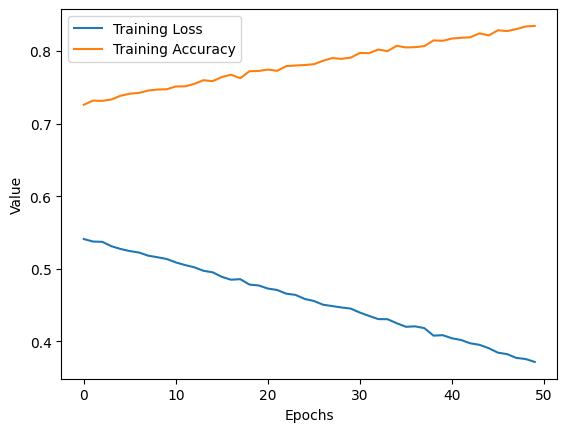

In [34]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.legend()
plt.show()

while performance has significatly increased in the training stage with accuracy reaching 83% and loss dropping into the 40s

the testing still reveals a very sligtly improved model accuracy: 0.6970 - loss: 0.6111

this suggests strong overfitting in which the model fits the training data too well but performs poorly in the test data

the simple models may be overfitted, so I want to try this same experiment with a more complex model

### More Complex CNN Model

#### Making the CNN Model

here i make a simple sequential CNN model like so:

Input layer -> Convolutional Layer 1 -> Pooling Layer 1 -> Convolutional Layer 2 -> Pooling Layer 2 -> Convolutional Layer 3 -> Pooling Layer 3 -> Flatten Layer -> Dense Layer -> Output Layer

The convolutional layers will use the ReLu activation function which outputs a 1 for positive inputs and 0 for negatives 

The final layer will use the sigmoid activation function which scales the output into a range between 0 and 1 and any values at > 0.5 become 1 and any < 0.5 become 0 

In [7]:
# https://www.tensorflow.org/guide/keras/sequential_model?hl=en

model3 = Sequential()

# Convolutional Layer 1
model3.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))

# Pooling Layer 1
model3.add(MaxPooling2D(pool_size=(2,2)))

# Convolutional Layer 2
model3.add(Conv2D(64, (3,3), activation='relu'))

# Pooling Layer 2
model3.add(MaxPooling2D(pool_size=(2,2)))

# Convolutional Layer 3
model3.add(Conv2D(128, (3,3), activation='relu'))

# Pooling Layer 3
model3.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model3.add(Flatten())

# Dense Layer
model3.add(Dense(64, activation='relu'))

# Output Layer
model3.add(Dense(1, activation='sigmoid'))

c:\Users\Matty\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### Model Shape and Size

In [8]:
model3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,699,009 (6.48 MB)

 Trainable params: 1,699,009 (6.48 MB)

 Non-trainable params: 0 (0.00 B)

#### Changing the learning rate 

Learning rate: from 0.001 to 0.0001
Epochs: from 5 to 10

In [9]:
# https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam

optimizer = Adam(learning_rate=0.0001)

#### Compiling the model with the tuned learning rate

In [10]:
# https://www.tensorflow.org/api_docs/python/tf/keras/Model

model3.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#### Training the model on 10 epochs

In [12]:
model3.fit(train_data, epochs=10)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 65s 249ms/step - accuracy: 0.6119 - loss: 0.6494
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 66s 261ms/step - accuracy: 0.6956 - loss: 0.5769
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 65s 256ms/step - accuracy: 0.7353 - loss: 0.5294
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 66s 262ms/step - accuracy: 0.7568 - loss: 0.4920
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 65s 257ms/step - accuracy: 0.7706 - loss: 0.4727
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 65s 257ms/step - accuracy: 0.7998 - loss: 0.4388
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 69s 275ms/step - accuracy: 0.8145 - loss: 0.4146
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 69s 273ms/step - accuracy: 0.8255 - loss: 0.3960
Epoch 9/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 69s 276ms/step - accuracy: 0.8355 - loss: 0.3730
Epoch 10/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 69s 276ms/step - accuracy: 0.8447 - loss: 0.3576


#### Testing and Evaluation of model on test data 10 epochs

Testing after training with 10 epochs

In [13]:
loss, acc = model3.evaluate(test_data)
print("Test accuracy:", acc)

64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.8092 - loss: 0.4222
Test accuracy: 0.8091942667961121


accuracy: 0.8092 - loss: 0.4222

really strong for 10 epochs

this tells me that the complex model is doing a much better job

This model is the best so far

#### Training the model on 25 epochs

In [14]:
model3.fit(train_data, epochs=25)

Epoch 1/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 85s 337ms/step - accuracy: 0.8537 - loss: 0.3429
Epoch 2/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 88s 349ms/step - accuracy: 0.8578 - loss: 0.3284
Epoch 3/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 83s 329ms/step - accuracy: 0.8646 - loss: 0.3122
Epoch 4/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 74s 295ms/step - accuracy: 0.8742 - loss: 0.3027
Epoch 5/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 71s 284ms/step - accuracy: 0.8780 - loss: 0.2879
Epoch 6/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 70s 278ms/step - accuracy: 0.8859 - loss: 0.2781
Epoch 7/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 71s 281ms/step - accuracy: 0.8934 - loss: 0.2648
Epoch 8/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 79s 268ms/step - accuracy: 0.9019 - loss: 0.2451
Epoch 9/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 68s 270ms/step - accuracy: 0.9076 - loss: 0.2359
Epoch 10/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 69s 275ms/step - accuracy: 0.9144 - loss: 0.2198
Epoch 11/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 69s 273ms/step - accuracy: 0.9176 - loss: 0.2117
Epoch 12/25
251/251

#### Testing and Evaluation of model on test data 25 epochs

Testing after training with 25 epochs

In [15]:
loss, acc = model3.evaluate(test_data)
print("Test accuracy:", acc)

64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.8087 - loss: 0.6167
Test accuracy: 0.8086999654769897


accuracy: 0.8087 - loss: 0.6167

thise model performed slightly poorer after 25 epochs when compared to after 10 epochs

this suggests overfitting but this could also be due to the complex model taking much longer time to learn so it could be a case that the performance dips for a bit midway, so I want to try this with 50 epoch to see if it changes

#### Training the model on 50 epochs

In [16]:
history = model3.fit(train_data, epochs=50)

Epoch 1/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 73s 290ms/step - accuracy: 0.9914 - loss: 0.0508
Epoch 2/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 81s 323ms/step - accuracy: 0.9935 - loss: 0.0438
Epoch 3/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 81s 323ms/step - accuracy: 0.9959 - loss: 0.0363
Epoch 4/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 90s 359ms/step - accuracy: 0.9950 - loss: 0.0355
Epoch 5/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 87s 346ms/step - accuracy: 0.9979 - loss: 0.0271
Epoch 6/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 89s 354ms/step - accuracy: 0.9964 - loss: 0.0271
Epoch 7/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 75s 298ms/step - accuracy: 0.9994 - loss: 0.0209
Epoch 8/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 89s 353ms/step - accuracy: 0.9976 - loss: 0.0200
Epoch 9/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 82s 324ms/step - accuracy: 0.9988 - loss: 0.0176
Epoch 10/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 80s 318ms/step - accuracy: 0.9988 - loss: 0.0171
Epoch 11/50
251/251 ━━━━━━━━━━━━━━━━━━━━ 70s 278ms/step - accuracy: 0.9965 - loss: 0.0225
Epoch 12/50
251/251

#### Testing and Evaluation of model on test data 25 epochs

Testing after training with 25 epochs

In [17]:
loss, acc = model3.evaluate(test_data)
print("Test accuracy:", acc)

64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.8023 - loss: 1.2120
Test accuracy: 0.8022738695144653


This model performs even worse

this suggests strong overfitting that more epochs doesnt always mean greater performance

The best model was the complex model at 10 epoch, this model is extremely overconfident and its makings lots of mistakes on the test data

#### Plot of Accuracy vs Loss over the 50 epoch Complex CNN

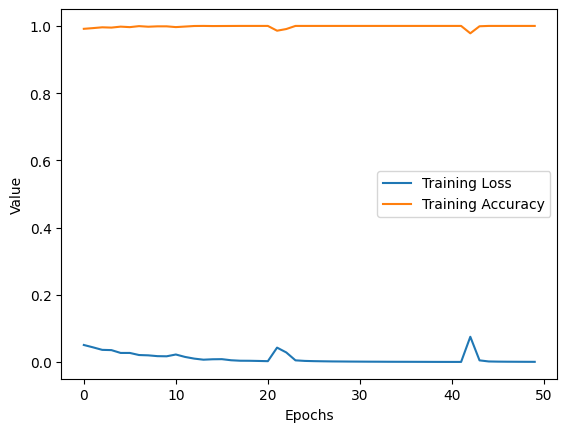

In [18]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.legend()
plt.show()

This model is the best on paper but in the testing phase it performs worse than most of the models

### Overall Evaluation of Test Data Results

#### Simple CNN Model - 0.001 learning rate, 5 epochs

accuracy: 0.4998 - loss: 0.6932

#### Tuned Simple CNN Model

##### 0.0001 learning rate, 10 epochs:

accuracy: 0.6139 - loss: 0.6545

##### 0.0001 learning rate, 25 epochs:

accuracy: 0.6826 - loss: 0.6025

##### 0.0001 learning rate, 50 epochs:

accuracy: 0.6970 - loss: 0.6111

#### Tuned Complex CNN Model

##### 0.0001 learning rate, 10 epochs:

accuracy: 0.8092 - loss: 0.4222 - BEST MODEL

##### 0.0001 learning rate, 25 epochs:

accuracy: 0.8087 - loss: 0.6167

##### 0.0001 learning rate, 50 epochs:

accuracy: 0.8023 - loss: 1.2120 


The results show that increasing the number of epochs doesnt always lead to a performance increase, it is however a balance between bias and variance that guides a strong model

its to say, the right combination of model complexity and epoch aswell as learning rate is what provided a strong model in this test.

whenever additional layers were added to the model, the performance was significantly increased, the performance initially dipped at 25 epoch, then it dipped further at 50 epoch, this suggests strong overfitting of the model 

So the best model was the complex CNN with 10 epoch and learning rate of 0.0001 which showed an accuracy of 0.8092 and loss of 0.4222 which has both the highest accuracy and the lowest loss of all models

Further write-up on the results in my report submission

## Matthew Riddell - Machine Learning Report:

The next few pages in the combined submission file are from the Report:

Please continue reading!

Also the link to the Github where all the files can be found:

https://github.com/Matthew-Riddell/Machine-Learning-CA2.2

The Report starts now!